# 0529 Sonnet single-stage on 0410 benchmark + Kimi re-eval experiment

Reproducible source for every metric in `comparison.md`.

| Pipeline | Model(s) | Stage |
|---|---|---|
| **0518 (production baseline)** | Haiku 4.5 + Kimi K2.5 | Two-stage extraction → classification |
| **0529 Sonnet** (this run) | Sonnet 4.6 | Single-stage |
| **0529 Sonnet+Reeval** (experiment) | Sonnet 4.6 + Kimi K2.5 | Single-stage + targeted re-eval |

All three use the same postprocess (`clean_treatments` → `derive_severity_direction` → `merge_to_labels`) and the same 22-entry TREATMENT_RANK taxonomy. Predictions are merged against `0410.csv` (PENDING / REMOVE / MANUAL excluded).

**Run id**: `3807d18f-4b45-4dfa-bb86-9aa9476319eb`.

In [14]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    cohen_kappa_score,
    f1_score,
)

sys.path.insert(0, str(Path('..').resolve() / 'citator-pipeline'))
from utils.postprocess import TREATMENT_RANK, severity_mapping, direction_mapping  # noqa: E402

DATA_DIR        = Path('data')
LABELS_FILE     = Path('..') / 'data' / 'benchmark_original' / '0410.csv'
BASELINE_DIR    = Path('..') / '..' / 'ai-research' / 'experiments_05182026' / 'data'

SEVERITY_ORDER     = ['Stop', 'Warning', 'Caution', 'Neutral']
SEVERITY_TO_RANK   = {s: i for i, s in enumerate(reversed(SEVERITY_ORDER))}  # Neutral=0, Stop=3
DIRECTION_ORDER    = ['Direct History', 'Citing Reference', 'Related Reference']

pd.set_option('display.max_rows', 60)
pd.set_option('display.max_colwidth', 80)

## 1. Load + re-merge predictions with labels

`matched_results.csv` keeps the predicted treatment / severity / caseHistory but not the label-side ground truth. Re-merge against `0410.csv` on `(citing_cluster_id, cited_cluster_id)` so we have pred + true side by side.

In [15]:
labels = pd.read_csv(LABELS_FILE)
labels = labels[~labels['final_treatment'].isin(['PENDING', 'REMOVE', 'MANUAL'])].copy()

def load_eval(matched_path):
    m = pd.read_csv(matched_path)
    m['citing_cluster_id'] = m['citing_cluster_id'].astype(int)
    return m.merge(
        labels[['citing_cluster_id', 'cited_cluster_id',
                'final_treatment', 'severity', 'direction']],
        on=['citing_cluster_id', 'cited_cluster_id'],
        how='inner',
        suffixes=('_pred', '_true'),
    ).rename(columns={
        'treatment':       'pred_treatment',
        'caseHistory':     'pred_direction',
        'severity_pred':   'pred_severity',
        'final_treatment': 'true_treatment',
        'severity_true':   'true_severity',
        'direction':       'true_direction',
    })

ed_0518   = load_eval(BASELINE_DIR / 'eval' / 'matched_results.csv')
ed_sonnet = load_eval(DATA_DIR / 'eval' / 'matched_results.csv')
ed_reeval = load_eval(DATA_DIR / 'eval_reeval' / 'matched_results.csv')

print(f'0518 Haiku+Kimi:    {len(ed_0518):>5,} rows  /  {ed_0518["citing_cluster_id"].nunique():>3} clusters')
print(f'0529 Sonnet:        {len(ed_sonnet):>5,} rows  /  {ed_sonnet["citing_cluster_id"].nunique():>3} clusters')
print(f'0529 Sonnet+Reeval: {len(ed_reeval):>5,} rows  /  {ed_reeval["citing_cluster_id"].nunique():>3} clusters')

0518 Haiku+Kimi:    8,856 rows  /  321 clusters
0529 Sonnet:        9,558 rows  /  327 clusters
0529 Sonnet+Reeval: 9,558 rows  /  327 clusters


## 2. Normalize treatments (strip "as recognized by")

0410 labels store base treatments only — `"Overruled as recognized by"` and `"Overruled by"` both compare as `"Overruled by"`. Matches how the 0518 eval normalizes.

In [16]:
def normalize_treatment(t):
    if pd.isna(t) or not t: return ''
    return t.replace(' as recognized by', ' by') if ' as recognized' in t else t

for ed in (ed_0518, ed_sonnet, ed_reeval):
    ed['pred_treatment_base'] = ed['pred_treatment'].apply(normalize_treatment)
    ed['true_treatment_base'] = ed['true_treatment'].apply(normalize_treatment)

ed_sonnet[['citing_cluster_id', 'pred_treatment', 'true_treatment',
           'pred_treatment_base', 'true_treatment_base']].head(5)

,citing_cluster_id,pred_treatment,true_treatment,pred_treatment_base,true_treatment_base
0,9622223,Reversed as recognized by,Reversed as recognized by,Reversed by,Reversed by
1,109505,Reversed by,Reversed by,Reversed by,Reversed by
2,117849,Reversed by,Reversed by,Reversed by,Reversed by
3,103395,Reversed by,Reversed by,Reversed by,Reversed by
4,103426,Reversed by,Reversed by,Reversed by,Reversed by


## 3. Headline metrics — three-way comparison

Treatment / severity / direction at the (citing, cited) pair level. Treatment metrics use the normalized base form.

In [17]:
def metrics_block(name, ed):
    yt_t = ed['true_treatment_base']; yp_t = ed['pred_treatment_base']
    yt_s = ed['true_severity'];       yp_s = ed['pred_severity']
    yt_d = ed['true_direction'];      yp_d = ed['pred_direction']
    return {
        'pipeline':      name,
        'rows':          len(ed),
        'clusters':      ed['citing_cluster_id'].nunique(),
        'T_acc':         (yt_t == yp_t).mean(),
        'T_macroF1':     f1_score(yt_t, yp_t, average='macro',    zero_division=0),
        'T_weightedF1':  f1_score(yt_t, yp_t, average='weighted', zero_division=0),
        'T_kappa':       cohen_kappa_score(yt_t, yp_t),
        'T_QWK':         cohen_kappa_score(
                            yt_t.map(TREATMENT_RANK).fillna(-1).astype(int),
                            yp_t.map(TREATMENT_RANK).fillna(-1).astype(int),
                            weights='quadratic'),
        'S_macroF1':     f1_score(yt_s, yp_s, average='macro',    zero_division=0),
        'S_kappa':       cohen_kappa_score(yt_s, yp_s),
        'S_QWK':         cohen_kappa_score(
                            yt_s.map(SEVERITY_TO_RANK).fillna(-1).astype(int),
                            yp_s.map(SEVERITY_TO_RANK).fillna(-1).astype(int),
                            weights='quadratic'),
        'D_macroF1':     f1_score(yt_d, yp_d, average='macro',    zero_division=0),
        'D_kappa':       cohen_kappa_score(yt_d, yp_d),
    }

summary = pd.DataFrame([
    metrics_block('0518 Haiku+Kimi',     ed_0518),
    metrics_block('0529 Sonnet',         ed_sonnet),
    metrics_block('0529 Sonnet+Reeval',  ed_reeval),
]).set_index('pipeline')

summary.style.format({c: '{:.4f}' for c in summary.columns if c not in ('rows','clusters')})

,rows,clusters,T_acc,T_macroF1,T_weightedF1,T_kappa,T_QWK,S_macroF1,S_kappa,S_QWK,D_macroF1,D_kappa
pipeline,,,,,,,,,,,,
0518 Haiku+Kimi,8856,321,0.9446,0.3821,0.9488,0.5848,0.6953,0.6095,0.5630,0.6556,0.8124,0.7020
0529 Sonnet,9558,327,0.9647,0.4729,0.9657,0.7076,0.7916,0.6068,0.7473,0.7680,0.8227,0.7033
0529 Sonnet+Reeval,9558,327,0.9589,0.4409,0.9624,0.6887,0.7853,0.5698,0.7020,0.7579,0.6148,0.7182


## 4. Apples-to-apples — Sonnet ∩ 0518 intersection

Restrict both pipelines to the (citing, cited) keys both matched. Removes the coverage advantage of any one pipeline.

In [18]:
def keys(ed):
    return set(zip(ed['citing_cluster_id'].astype(int), ed['cited_cluster_id'].astype(int)))

k_0518   = keys(ed_0518)
k_sonnet = keys(ed_sonnet)
shared   = k_0518 & k_sonnet
print(f'Sonnet ∩ 0518 keys: {len(shared):,}')

def restrict(ed, key_set):
    k = list(zip(ed['citing_cluster_id'].astype(int), ed['cited_cluster_id'].astype(int)))
    mask = [x in key_set for x in k]
    return ed.loc[mask].copy()

ed_0518_int   = restrict(ed_0518,   shared)
ed_sonnet_int = restrict(ed_sonnet, shared)

summary_int = pd.DataFrame([
    metrics_block('0518 (∩)',         ed_0518_int),
    metrics_block('0529 Sonnet (∩)',  ed_sonnet_int),
]).set_index('pipeline')

summary_int.style.format({c: '{:.4f}' for c in summary_int.columns if c not in ('rows','clusters')})

Sonnet ∩ 0518 keys: 8,808


,rows,clusters,T_acc,T_macroF1,T_weightedF1,T_kappa,T_QWK,S_macroF1,S_kappa,S_QWK,D_macroF1,D_kappa
pipeline,,,,,,,,,,,,
0518 (∩),8828,321,0.9448,0.3861,0.9492,0.5849,0.6953,0.6106,0.5624,0.6563,0.8113,0.7004
0529 Sonnet (∩),8828,321,0.9657,0.4861,0.9665,0.7183,0.7915,0.6048,0.7500,0.7667,0.8255,0.7158


## 5. Direct History vs Other split

Sonnet's DH performance is the largest single-metric gap vs the 0518 baseline. Other = Citing Reference + Related Reference.

In [19]:
def split_metrics(name, ed):
    rows = []
    for slice_name, sub in [('Direct History', ed[ed['true_direction']=='Direct History']),
                            ('Other',          ed[ed['true_direction']!='Direct History'])]:
        if len(sub) == 0:
            continue
        yt = sub['true_treatment_base']; yp = sub['pred_treatment_base']
        rows.append({
            'pipeline':   name,
            'slice':      slice_name,
            'n':          len(sub),
            'T_macroF1':  f1_score(yt, yp, average='macro', zero_division=0),
            'T_kappa':    cohen_kappa_score(yt, yp),
            'T_QWK':      cohen_kappa_score(
                yt.map(TREATMENT_RANK).fillna(-1).astype(int),
                yp.map(TREATMENT_RANK).fillna(-1).astype(int),
                weights='quadratic'),
            'S_kappa':    cohen_kappa_score(sub['true_severity'], sub['pred_severity']),
        })
    return rows

split_table = pd.DataFrame(
    split_metrics('0518',   ed_0518) +
    split_metrics('Sonnet', ed_sonnet) +
    split_metrics('Reeval', ed_reeval)
).set_index(['pipeline','slice'])

split_table.style.format({c: '{:.4f}' for c in ('T_macroF1','T_kappa','T_QWK','S_kappa')})

## 6. Per-class treatment F1 (top supported classes)

In [20]:
TOP_CLASSES = [
    'Cited by', 'Distinguished by', 'Cert. denied by', 'Affirmed by',
    'Reversed by', 'Overruled by', 'Reversed and remanded by',
    'Abrogated by', 'Limited by', 'Vacated and remanded by',
]

rows = []
for name, ed in [('0518', ed_0518), ('Sonnet', ed_sonnet), ('Sonnet+Reeval', ed_reeval)]:
    yt = ed['true_treatment_base']; yp = ed['pred_treatment_base']
    report = classification_report(yt, yp, zero_division=0, output_dict=True)
    for t in TOP_CLASSES:
        r = report.get(t, {'precision': 0, 'recall': 0, 'f1-score': 0, 'support': 0})
        rows.append({
            'pipeline': name, 'treatment': t,
            'P': r['precision'], 'R': r['recall'], 'F1': r['f1-score'],
            'support': int(r['support']),
        })
per_class = pd.DataFrame(rows).pivot(index='treatment', columns='pipeline', values='F1').reindex(TOP_CLASSES)
per_class.style.format('{:.3f}').background_gradient(cmap='YlGn', axis=None)

pipeline,0518,Sonnet,Sonnet+Reeval
treatment,,,
Cited by,0.974,0.983,0.980
Distinguished by,0.527,0.769,0.695
Cert. denied by,0.653,0.618,0.695
Affirmed by,0.641,0.677,0.709
Reversed by,0.577,0.789,0.796
Overruled by,0.659,0.711,0.736
Reversed and remanded by,0.520,0.667,0.692
Abrogated by,0.000,0.000,0.000
Limited by,0.231,0.625,0.455


## 7. Cert. denied analysis

Sonnet's `citator` prompt has a CRITICAL pattern recognition block for cert chains (lower-court citation = TARGET; supreme-court order = APPLIER). The block was ported from `kimi_classifier`.

In [21]:
def cert_denied_pr_f1(name, ed):
    yt = ed['true_treatment_base']; yp = ed['pred_treatment_base']
    pred_cd = (yp == 'Cert. denied by')
    true_cd = (yt == 'Cert. denied by')
    both    = (pred_cd & true_cd).sum()
    p = both / pred_cd.sum() if pred_cd.sum() else 0.0
    r = both / true_cd.sum() if true_cd.sum() else 0.0
    f1 = (2*p*r)/(p+r) if (p+r) else 0.0
    return {'pipeline': name, 'pred': int(pred_cd.sum()),
            'true': int(true_cd.sum()), 'both': int(both),
            'P': p, 'R': r, 'F1': f1}

cert = pd.DataFrame([
    cert_denied_pr_f1('0518',          ed_0518),
    cert_denied_pr_f1('Sonnet',        ed_sonnet),
    cert_denied_pr_f1('Sonnet+Reeval', ed_reeval),
]).set_index('pipeline')
cert.style.format({'P': '{:.3f}', 'R': '{:.3f}', 'F1': '{:.3f}'})

,pred,true,both,P,R,F1
pipeline,,,,,,
0518,109,87,64,0.587,0.736,0.653
Sonnet,95,96,59,0.621,0.615,0.618
Sonnet+Reeval,166,96,91,0.548,0.948,0.695


## 8. Top confusion pairs

Most frequent (true → pred) mismatches in each pipeline's matched eval set.

In [22]:
def top_confusions(ed, n=8):
    yt = ed['true_treatment_base']; yp = ed['pred_treatment_base']
    conf = pd.crosstab(yt, yp)
    errors = []
    for tt in conf.index:
        for pt in conf.columns:
            if tt != pt:
                c = conf.loc[tt, pt]
                if c > 0:
                    errors.append((tt, pt, c))
    errors.sort(key=lambda x: -x[2])
    return pd.DataFrame(errors[:n], columns=['true', 'pred', 'n'])

for name, ed in [('0518', ed_0518), ('0529 Sonnet', ed_sonnet), ('0529 Sonnet+Reeval', ed_reeval)]:
    print(f'\n--- {name} ---')
    print(top_confusions(ed).to_string(index=False))


--- 0518 ---
            true             pred   n
        Cited by Distinguished by 175
Distinguished by         Cited by  54
        Cited by  Cert. denied by  41
 Cert. denied by         Cited by  20
        Cited by      Affirmed by  19
     Affirmed by         Cited by  17
        Cited by     Overruled by  16
    Abrogated by         Cited by  14

--- 0529 Sonnet ---
            true             pred  n
        Cited by Distinguished by 60
        Cited by      Affirmed by 43
 Cert. denied by         Cited by 34
Distinguished by         Cited by 33
        Cited by  Cert. denied by 32
    Abrogated by         Cited by 17
        Cited by     Overruled by 17
     Affirmed by         Cited by 10

--- 0529 Sonnet+Reeval ---
            true                  pred  n
        Cited by      Distinguished by 93
        Cited by       Cert. denied by 73
        Cited by           Affirmed by 37
Distinguished by              Cited by 29
    Abrogated by              Cited by 17
        Ci

## 9. Treatment rank distance distribution

Distance between predicted and true treatment on the 0–21 TREATMENT_RANK ordinal scale. 11–21 = far-tier inversions (most damaging in a citator UI).

In [23]:
def rank_distance(ed):
    tr = ed['true_treatment_base'].map(TREATMENT_RANK)
    pr = ed['pred_treatment_base'].map(TREATMENT_RANK)
    return (tr - pr).abs()

buckets = [('0 (exact)',          0, 0),
           ('1-3 (within-tier)',  1, 3),
           ('4-5',                4, 5),
           ('6-10',               6, 10),
           ('11-21 (far)',        11, 21)]

rd_rows = []
for name, ed in [('0518', ed_0518), ('0529 Sonnet', ed_sonnet), ('0529 Sonnet+Reeval', ed_reeval)]:
    rd = rank_distance(ed)
    total = len(ed)
    rd_rows.append({
        'pipeline': name,
        **{lbl: f"{((rd >= lo) & (rd <= hi)).sum()} ({100*((rd >= lo) & (rd <= hi)).sum()/total:.1f}%)"
           for lbl, lo, hi in buckets},
    })
pd.DataFrame(rd_rows).set_index('pipeline')

,0 (exact),1-3 (within-tier),4-5,6-10,11-21 (far)
pipeline,,,,,
0518,8365 (94.5%),122 (1.4%),242 (2.7%),34 (0.4%),93 (1.1%)
0529 Sonnet,9221 (96.5%),143 (1.5%),99 (1.0%),20 (0.2%),73 (0.8%)
0529 Sonnet+Reeval,9165 (95.9%),150 (1.6%),141 (1.5%),28 (0.3%),72 (0.8%)


## 10. Direction + Severity confusion matrices

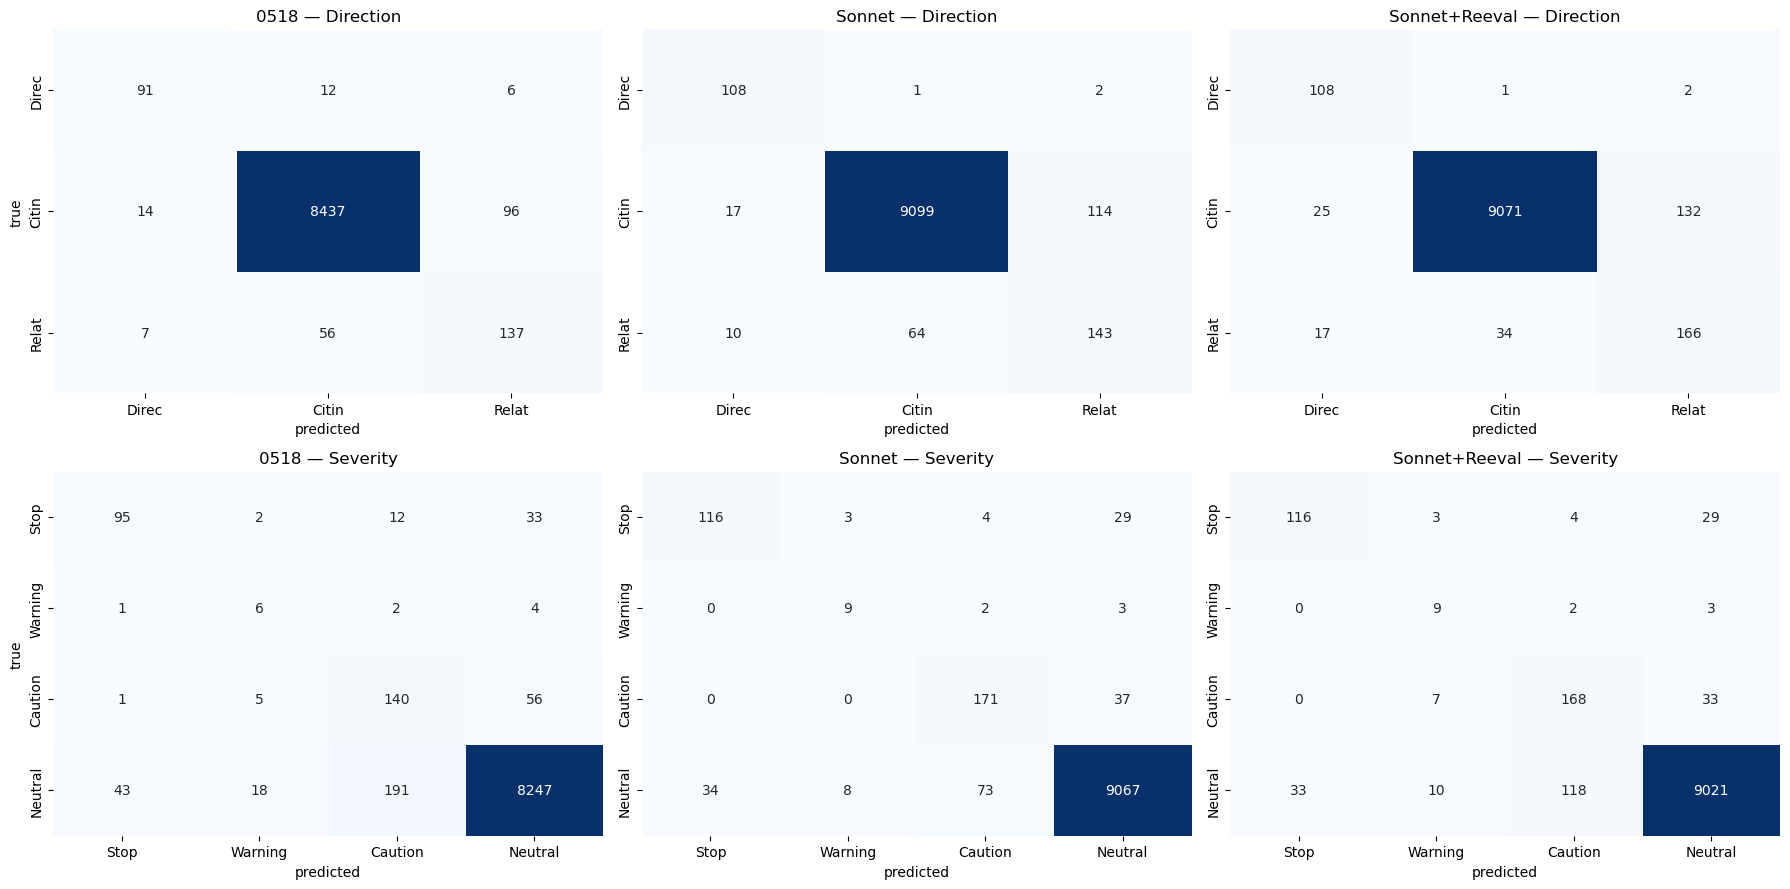

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for col, (name, ed) in enumerate([('0518', ed_0518), ('Sonnet', ed_sonnet), ('Sonnet+Reeval', ed_reeval)]):
    cm_d = confusion_matrix(ed['true_direction'], ed['pred_direction'], labels=DIRECTION_ORDER)
    sns.heatmap(cm_d, annot=True, fmt='d', cmap='Blues',
                xticklabels=[s[:5] for s in DIRECTION_ORDER], yticklabels=[s[:5] for s in DIRECTION_ORDER],
                ax=axes[0, col], cbar=False)
    axes[0, col].set_title(f'{name} — Direction')
    axes[0, col].set_xlabel('predicted'); axes[0, col].set_ylabel('true' if col == 0 else '')
    cm_s = confusion_matrix(ed['true_severity'], ed['pred_severity'], labels=SEVERITY_ORDER)
    sns.heatmap(cm_s, annot=True, fmt='d', cmap='Blues',
                xticklabels=SEVERITY_ORDER, yticklabels=SEVERITY_ORDER,
                ax=axes[1, col], cbar=False)
    axes[1, col].set_title(f'{name} — Severity')
    axes[1, col].set_xlabel('predicted'); axes[1, col].set_ylabel('true' if col == 0 else '')
plt.tight_layout()

## 11. Reeval transition analysis

Which Sonnet predictions did Kimi re-eval change? Was each change correct? The per-row delta tells us whether reeval is net-positive.

In [25]:
joined = (
    ed_sonnet[['citing_cluster_id','cited_cluster_id','pred_treatment_base','true_treatment_base']]
       .rename(columns={'pred_treatment_base':'sonnet_t'})
       .merge(
           ed_reeval[['citing_cluster_id','cited_cluster_id','pred_treatment_base']]
              .rename(columns={'pred_treatment_base':'reeval_t'}),
           on=['citing_cluster_id','cited_cluster_id'], how='inner',
       )
)

changed = joined[joined['sonnet_t'] != joined['reeval_t']].copy()
print(f'{len(changed)} predictions changed by reeval ({100*len(changed)/len(joined):.1f}% of {len(joined)})\n')

trans = changed.groupby(['sonnet_t','reeval_t']).size().sort_values(ascending=False).head(10)
print('Top transitions (sonnet → reeval):')
for (st, rt), n in trans.items():
    print(f'  {st[:32]:32s} → {rt[:32]:32s} n={n}')

ys = changed['sonnet_t']; yr = changed['reeval_t']; yt = changed['true_treatment_base']
fixed       = ((ys != yt) & (yr == yt)).sum()
broke       = ((ys == yt) & (yr != yt)).sum()
both_wrong  = ((ys != yt) & (yr != yt)).sum()
both_right  = ((ys == yt) & (yr == yt)).sum()
print(f'\nOf {len(changed)} changes:')
print(f'  fixed (Sonnet wrong  →  reeval right) : {fixed}')
print(f'  broke (Sonnet right  →  reeval wrong) : {broke}')
print(f'  both wrong (different label)          : {both_wrong}')
print(f'  both right (rephrase)                 : {both_right}')
print(f'  net per-row delta: {fixed - broke:+d}')

212 predictions changed by reeval (2.2% of 9598)

Top transitions (sonnet → reeval):
  Cited by                         → Cert. denied by                  n=81
  Cited by                         → Distinguished by                 n=56
  Distinguished by                 → Declined to follow by            n=16
  Cert. denied by                  → Cited by                         n=8
  Affirmed by                      → Cited by                         n=8
  Distinguished by                 → Limited by                       n=6
  Distinguished by                 → Criticized by                    n=5
  Distinguished by                 → Cited by                         n=5
  Overruled by                     → Cited by                         n=3
  Cited by                         → Questioned by                    n=3

Of 212 changes:
  fixed (Sonnet wrong  →  reeval right) : 66
  broke (Sonnet right  →  reeval wrong) : 122
  both wrong (different label)          : 24
  both right (rephr

**Reeval is net-negative per-row** on this Sonnet base. The `flag_for_review` categories were designed for a more error-prone Sonnet baseline; on 0529 the `citator` prompt already covers cert chains and citation signals, so the flag set now routes mostly correct predictions to Kimi, which over-flips them on the dominant error classes (Cited by → Distinguished by / Cert. denied by).

## 12. Coverage diagnosis — token usage from raw Bedrock output

Sanity check that `SONNET_MAX_TOKENS = 64000` (Sonnet 4.6's ceiling) actually eliminated the silent truncation that would happen at lower caps. Reads the raw Bedrock batch output.

Records: 386  truncated (max_tokens): 0
Output tokens — min=333, median=5497, max=41478
Records emitting >16K tokens (would truncate under a 16K cap): 32
Records emitting >32K tokens:                                  3


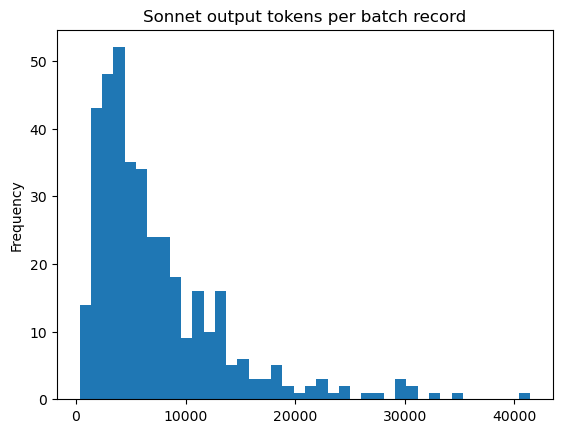

In [26]:
import json

RAW = DATA_DIR / 'scratch' / '3807d18f-4b45-4dfa-bb86-9aa9476319eb' / 'sonnet_raw' / 'input.jsonl.out'

rows = []
if RAW.exists():
    with open(RAW) as f:
        for line in f:
            rec = json.loads(line)
            mo = rec.get('modelOutput', {})
            u  = mo.get('usage', {})
            rows.append({
                'recordId': rec.get('recordId', ''),
                'stop_reason':   mo.get('stop_reason'),
                'input_tokens':  u.get('input_tokens', 0),
                'output_tokens': u.get('output_tokens', 0),
            })
    df = pd.DataFrame(rows)
    print(f'Records: {len(df)}  truncated (max_tokens): {(df["stop_reason"]=="max_tokens").sum()}')
    print(f'Output tokens — min={df["output_tokens"].min()}, median={int(df["output_tokens"].median())}, '
          f'max={df["output_tokens"].max()}')
    print(f'Records emitting >16K tokens (would truncate under a 16K cap): {(df["output_tokens"]>16000).sum()}')
    print(f'Records emitting >32K tokens:                                  {(df["output_tokens"]>32000).sum()}')
    df['output_tokens'].plot.hist(bins=40, title='Sonnet output tokens per batch record')
else:
    print(f'Raw output not on disk at {RAW}; skip on cold checkout')

## 13. Decomposed cost model

Cost = **A** × opinion-text-M-tokens + **B** × cases

- **A** = variable rate per 1M opinion-text tokens (model input rate + output amortized to opinion volume)
- **B** = fixed cost per case (prompt overhead per call + downstream stage costs that don't track opinion size)

Reconstructed from the benchmark run's actual token counts (Sonnet) and the published 0518 totals.

**Bedrock batch rates assumed**: Sonnet 4.6: $1.50/M input, $7.50/M output. Haiku 4.5: $0.40/M input, $2.00/M output. Kimi K2.5: ~$0.18/M input, ~$2.00/M output (inferred from 0518's Stage 2 totals).

In [27]:
# Constants — totals come from the actual run (Sonnet) and the 0518 readme.
TOTAL_0518          = 18.66     # batch, from 0518 readme
TOTAL_0529_SONNET   = 35.54     # batch, from Bedrock raw output (cell 26)
TOTAL_0529_REEVAL   = 36.04     # Sonnet $35.54 + ~$0.50 Kimi reeval

N_CASES             = 383       # same 0410 benchmark for all pipelines
OPINION_TEXT_M      = 6.4       # estimated opinion text tokens (same for both — same opinions)

# Model rates (Bedrock batch — 50% off on-demand)
SONNET_IN, SONNET_OUT = 1.50, 7.50     # $/M
HAIKU_IN,  HAIKU_OUT  = 0.40, 2.00

# Stage 1 / Sonnet token counts
SONNET_INPUT_M, SONNET_OUTPUT_M = 9.46, 2.85   # from raw .jsonl.out (cell 26)
HAIKU_INPUT_M,  HAIKU_OUTPUT_M  = 7.20, 0.40   # from 0518 readme (output estimated)

# === 0529 Sonnet (single-stage) ===
# Variable rate A_0529: input cost on opinion text + output amortized
output_per_opinion_text_0529 = SONNET_OUTPUT_M / OPINION_TEXT_M
A_0529 = SONNET_IN + SONNET_OUT * output_per_opinion_text_0529

# Fixed cost B_0529: prompt overhead (total Sonnet input - opinion text) × input rate ÷ cases
prompt_overhead_input_0529 = SONNET_INPUT_M - OPINION_TEXT_M
B_0529 = prompt_overhead_input_0529 * SONNET_IN / N_CASES

# === 0518 Haiku+Kimi (two-stage) ===
# A_0518: Stage 1 Haiku rate + Stage 1 output amortized
stage1_output_per_opinion_text = HAIKU_OUTPUT_M / OPINION_TEXT_M
A_0518 = HAIKU_IN + HAIKU_OUT * stage1_output_per_opinion_text

# B_0518: Stage 1 prompt overhead + entire Stage 2 cost (scales with cited-cases per cluster, not opinion size)
stage1_prompt_overhead = HAIKU_INPUT_M - OPINION_TEXT_M
stage1_prompt_cost = stage1_prompt_overhead * HAIKU_IN
stage1_total_cost  = HAIKU_INPUT_M * HAIKU_IN + HAIKU_OUTPUT_M * HAIKU_OUT
stage2_total_cost  = TOTAL_0518 - stage1_total_cost     # remainder is Kimi Stage 2
B_0518 = (stage1_prompt_cost + stage2_total_cost) / N_CASES

# === 0529 Sonnet+Reeval ===
# Reeval adds ~$0.50 / 383 cases ≈ $0.0013 per case to B; A unchanged
B_REEVAL = B_0529 + (TOTAL_0529_REEVAL - TOTAL_0529_SONNET) / N_CASES

# Display
summary = pd.DataFrame([
    {'pipeline': '0518 Haiku+Kimi',     'A ($/1M opinion-text)': A_0518,  'B ($/case)': B_0518,  'reconstructed': A_0518 * OPINION_TEXT_M + B_0518 * N_CASES,  'actual': TOTAL_0518},
    {'pipeline': '0529 Sonnet',          'A ($/1M opinion-text)': A_0529,  'B ($/case)': B_0529,  'reconstructed': A_0529 * OPINION_TEXT_M + B_0529 * N_CASES,  'actual': TOTAL_0529_SONNET},
    {'pipeline': '0529 Sonnet+Reeval',  'A ($/1M opinion-text)': A_0529,  'B ($/case)': B_REEVAL, 'reconstructed': A_0529 * OPINION_TEXT_M + B_REEVAL * N_CASES, 'actual': TOTAL_0529_REEVAL},
]).set_index('pipeline')
summary.style.format({'A ($/1M opinion-text)': '${:.2f}', 'B ($/case)': '${:.4f}',
                       'reconstructed': '${:.2f}', 'actual': '${:.2f}'})

,A ($/1M opinion-text),B ($/case),reconstructed,actual
pipeline,,,,
0518 Haiku+Kimi,$0.53,$0.0399,$18.66,$18.66
0529 Sonnet,$4.84,$0.0120,$35.57,$35.54
0529 Sonnet+Reeval,$4.84,$0.0133,$36.07,$36.04


**Asymmetry:** A_0518 is ~9× lower than A_0529 (Haiku is cheap per token). B_0518 is ~3.3× higher than B_0529 (Stage 2 Kimi makes ~10.75 calls per cluster, all counted as per-case overhead since they don't scale with opinion size). This trade-off means the cheaper pipeline depends on the opinion-size distribution.

### Cost crossover

Solve $A_{0529} \cdot T + B_{0529} = A_{0518} \cdot T + B_{0518}$ for $T$, the opinion-text tokens per case at which the two pipelines have equal cost.

In [28]:
T_crossover_M = (B_0518 - B_0529) / (A_0529 - A_0518)
T_crossover_tokens = T_crossover_M * 1e6
avg_tokens_per_case = OPINION_TEXT_M * 1e6 / N_CASES

print(f'Cost crossover: {T_crossover_tokens:,.0f} opinion-text tokens per case')
print(f'  Below this:  0529 Sonnet is cheaper per case (low B dominates)')
print(f'  Above this:  0518 Haiku+Kimi is cheaper per case (low A dominates)')
print(f'  Benchmark avg: {avg_tokens_per_case:,.0f} tokens per case — 0518 wins at this distribution')

Cost crossover: 6,481 opinion-text tokens per case
  Below this:  0529 Sonnet is cheaper per case (low B dominates)
  Above this:  0518 Haiku+Kimi is cheaper per case (low A dominates)
  Benchmark avg: 16,710 tokens per case — 0518 wins at this distribution


### Production extrapolation

Plug different workload shapes into `cost = A × M_tokens + B × N_cases`.

In [29]:
def estimate(name, n_cases, tokens_per_case):
    M = n_cases * tokens_per_case / 1e6
    return {
        'workload':           name,
        'cases':              n_cases,
        'tokens/case':        tokens_per_case,
        'opinion-text M':     M,
        '0518 Haiku+Kimi':    A_0518 * M + B_0518 * n_cases,
        '0529 Sonnet':        A_0529 * M + B_0529 * n_cases,
        '0529 Sonnet+Reeval': A_0529 * M + B_REEVAL * n_cases,
    }

workloads = pd.DataFrame([
    estimate('benchmark (this run)',                        383,     int(avg_tokens_per_case)),
    estimate('100K cases × 5K tokens (short opinions)',      100_000,  5_000),
    estimate('100K cases × 20K tokens (typical)',            100_000, 20_000),
    estimate('100K cases × 50K tokens (SCOTUS-heavy)',       100_000, 50_000),
    estimate('1M cases × 20K tokens (full-scale)',         1_000_000, 20_000),
]).set_index('workload')

workloads.style.format({
    'opinion-text M':     '{:,.1f}M',
    '0518 Haiku+Kimi':    '${:,.0f}',
    '0529 Sonnet':        '${:,.0f}',
    '0529 Sonnet+Reeval': '${:,.0f}',
    'cases':              '{:,}',
    'tokens/case':        '{:,}',
})

,cases,tokens/case,opinion-text M,0518 Haiku+Kimi,0529 Sonnet,0529 Sonnet+Reeval
workload,,,,,,
benchmark (this run),383,"16,710",6.4M,$19,$36,$36
100K cases × 5K tokens (short opinions),"100,000","5,000",500.0M,"$4,257","$3,618","$3,749"
100K cases × 20K tokens (typical),"100,000","20,000","2,000.0M","$5,045","$10,878","$11,009"
100K cases × 50K tokens (SCOTUS-heavy),"100,000","50,000","5,000.0M","$6,620","$25,398","$25,528"
1M cases × 20K tokens (full-scale),"1,000,000","20,000","20,000.0M","$50,448","$108,781","$110,087"


### Wrinkles in the model

1. **B is averaged across cited-case density.** For 0518, Stage 2 cost (~$15 of $18.66) scales with cited-cases per opinion (~10.75 Stage 2 calls/cluster on this benchmark), not opinion size. An opinion mix with unusually many or few cites per opinion will shift B for 0518; 0529 single-stage is more robust here.
2. **Pagination amplifies B.** Prompt is paid per *page*, not per case. Only 3/383 paginated here (1.008 pages/case). A workload of very large opinions paginating 3-5× would multiply B for 0529 roughly proportionally.
3. **Output cost folded into A.** Output is amortized to opinion-text volume on the assumption that bigger opinions emit more cases and more output. Different output:input ratios in production would shift A.
4. **Tool schema is part of B**, paid per call at the input rate.
5. **Prompt caching would slash B by ~12×** if Bedrock batch supported it. Cache reads at ~10% of input rate would drop 0529's B from $0.012 to ~$0.001 — shifting the crossover point dramatically. Today on Bedrock batch, no caching.
6. **Reeval adds +$0.001/case** to B. Not material to the cost story; just a fact.

## 14. Headline takeaways

1. **0529 Sonnet single-stage wins every agreement metric vs 0518 Haiku+Kimi**. Treatment macro F1 0.47 vs 0.38 (+0.09); κ 0.71 vs 0.58 (+0.13); QWK 0.79 vs 0.70 (+0.10).
2. **Best coverage**: 327 clusters / 9,558 matched rows (vs 0518's 321 / 8,856).
3. **Direct History is essentially solved**: treatment macro F1 0.80, QWK 0.94.
4. **Cert. denied recovered to F1 0.62** via the prompt's CRITICAL pattern block — no re-eval needed.
5. **Kimi re-eval is net-negative on this base** (66 fixed / 122 broke per-row; treatment macro F1 −0.03; severity κ −0.05). Not part of the candidate setup. Code path stays in the repo for future re-tuning of `flag_for_review`.
6. **Cost: $35.54 batch** ($0.093/case). ~1.9× Haiku+Kimi but ~2.2× cheaper than on-demand Sonnet.
7. **Cost crossover at ~6,500 opinion-text tokens per case** (per the decomposed model in §13). Below: 0529 Sonnet cheaper per case. Above: 0518 Haiku+Kimi cheaper. Benchmark avg 16.7K tokens/case puts 0518 on the cheaper side at this distribution; production cost competitiveness depends on the opinion-size mix.